# Exploratory data analysis (EDA) notebook

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from src.lib import ThinFilmDatabase

Load thin films database\
Samples TL10_5 and TL10_7.5, which are respectively $TiO$ and $Ti_2O_3$, have missing `rutile_fraction` ans `crystallite_size` parameters.

In [3]:
df = ThinFilmDatabase.load_df()
print(df.to_string())

           thickness_nm  oxygen_pressure  stoichiometry_x  rutile_fraction  epsilon_serial  epsilon_parallel  effective_mass  crystallite_size
sample_id                                                                                                                                     
TL10_5            280.0              5.0     1.000000e+00              NaN             1.0               1.0             7.0               NaN
TL10_7.5          280.0              7.5     5.000000e-01              NaN             5.0               5.0             6.0               NaN
TL10_10           360.0             10.0     6.584320e-02              1.0           127.0             127.0            20.0              4.32
TL10_15           400.0             15.0     7.426990e-05              1.0           127.0             127.0            20.0              9.91
TL10_17.5         330.0             17.5     8.230300e-06              0.6            73.5              94.2            12.4             12.20

For EDA `seaborn` and `pandas` libraries are used.
First correlation of columns in the dataframe is evaluated using [pandas.DataFrame.corr](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html) function.

>> A statistical summary of the DataFrame
                  count        mean        std     min           25%         50%         75%    max
thickness_nm        8.0  320.000000  54.772256  230.00  2.800000e+02  325.000000  360.000000  400.0
oxygen_pressure     8.0   16.250000   8.660254    5.00  9.375000e+00   16.250000   21.250000   30.0
stoichiometry_x     8.0    0.195741   0.367971    0.00  6.280500e-07    0.000041    0.174382    1.0
rutile_fraction     6.0    0.500000   0.438178    0.00  1.500000e-01    0.450000    0.900000    1.0
epsilon_serial      8.0   60.300000  47.883460    1.00  3.500000e+01   51.950000   86.875000  127.0
epsilon_parallel    8.0   65.250000  48.984750    1.00  3.500000e+01   61.400000  102.400000  127.0
effective_mass      8.0    9.500000   7.280699    1.00  5.225000e+00    6.850000   14.300000   20.0
crystallite_size    6.0   12.485000   4.991864    4.32  1.048250e+01   13.100000   15.410000   18.6

>> Pairwise correlation of columns


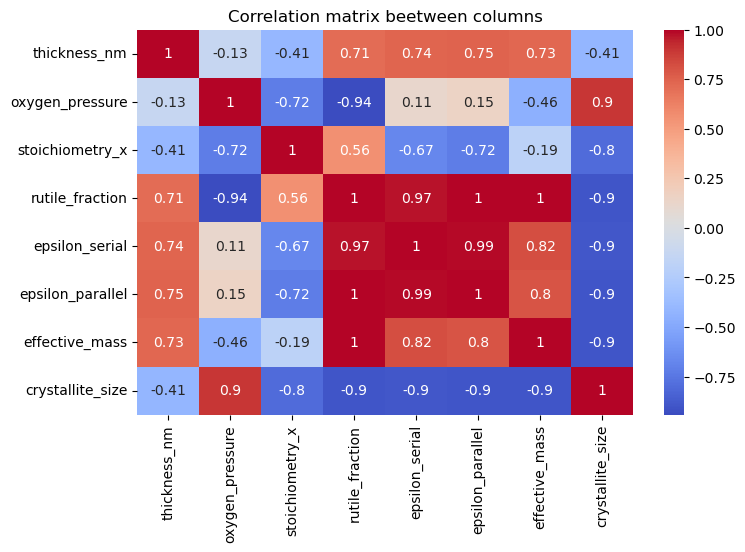

In [4]:
print(">> A statistical summary of the DataFrame")
print( df.describe().T.to_string() )

# to count # of appearances i.e. for histogram one may use DataFrame.value_counts()
# print( df['thickness_nm'].value_counts() )

print("\n>> Pairwise correlation of columns")
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation matrix beetween columns')
plt.show()

Plotting the average crystallite size vs. the non-stoichiometry parameter `x` and an oxygen pressure during deposition

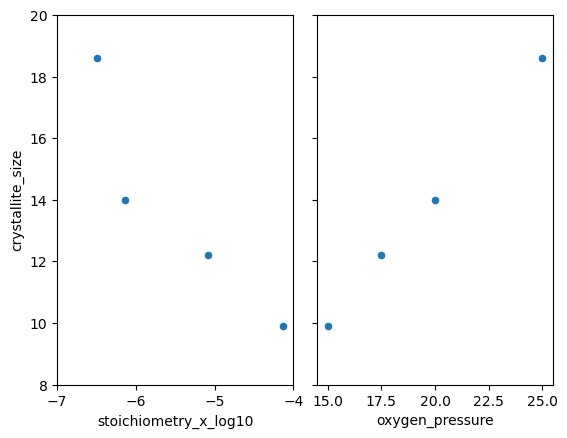

In [5]:
df_rutile = df['TL10_15':'TL10_25']
df_rutile['stoichiometry_x_log10'] = df_rutile['stoichiometry_x'].apply(np.log10).to_numpy()

fig, ax = plt.subplots(1, 2, sharey=True, gridspec_kw={'wspace': 0.1})
df_rutile.plot.scatter('stoichiometry_x_log10', 'crystallite_size', ax=ax[0])
df_rutile.plot.scatter('oxygen_pressure', 'crystallite_size', ax=ax[1])
ax[0].set_ylim(8, 20)
ax[0].set_xticks([-7, -6, -5, -4])
plt.show()

Dataframe of conductivity, temperature is rouded to create it

In [6]:
data = {}
for s in df.index:
    cond = ThinFilmDatabase.read_conductivity(s)
    data[s] = pd.Series(cond.to_numpy(), index=cond.index.round())
df_cond = pd.DataFrame(data)

print('>> Conductivity DataFrame')
print(df_cond.head().to_string())

print('\n>> Number of missing conductivity data')
print(df_cond.apply(func=pd.DataFrame.isnull, axis=1).sum().to_string())

print('\n>> Datasets description')
print(df_cond.describe().T.to_string())

>> Conductivity DataFrame
               TL10_5  TL10_7.5   TL10_10  TL10_15  TL10_17.5  TL10_20  TL10_25  TL10_30
temperature                                                                             
30.0         8.357143  0.009429       NaN      NaN        NaN      NaN      NaN      NaN
32.0         8.464286  0.009857  0.000803      NaN        NaN      NaN      NaN      NaN
34.0         8.571429  0.010250  0.000839      NaN        NaN      NaN      NaN      NaN
36.0         8.642857  0.010643  0.000881      NaN        NaN      NaN      NaN      NaN
38.0         8.750000  0.011071  0.000925      NaN        NaN      NaN      NaN      NaN

>> Number of missing conductivity data
TL10_5        8
TL10_7.5      2
TL10_10       3
TL10_15       9
TL10_17.5    21
TL10_20      23
TL10_25      25
TL10_30      27

>> Datasets description
           count          mean           std           min           25%           50%           75%           max
TL10_5      32.0  1.343192e+01  5.333962e+0

<Figure size 640x480 with 0 Axes>

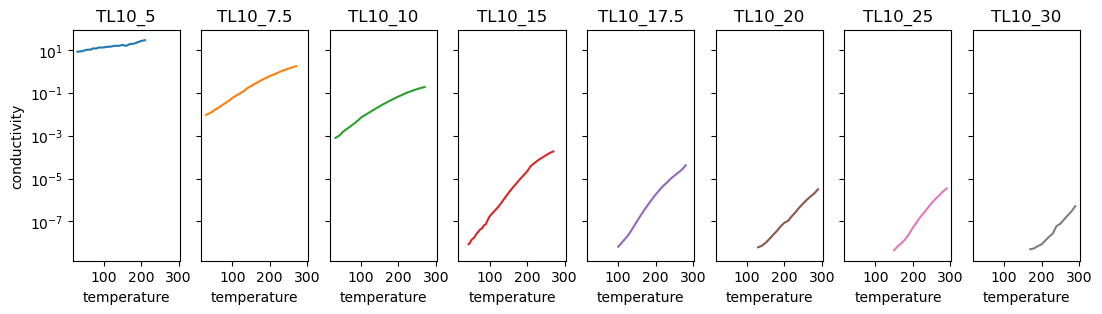

In [26]:
plt.figure()
df_cond.plot(logy=True, subplots=True, ylabel='conductivity', legend=False, title=df_cond.columns.to_list(),
    layout=(1, df_cond.shape[1]), sharey=True, figsize=(13, 3))
plt.show()